# k-Nearest Neighbors (kNN)
* **obiettivo**: classificare (ossia etichettare) un punto $x$, in base all'etichetta che compare di piu nei $k$ punti piu' vicini.

* **classificare**: punto $x$ in base alle etichette dei $k$ punti piu' vicini nel dataset etichettato.

* **apprendimento**: consiste nel memorizzare il **dataset di apprendimento**

# Codifica
* **fitting**: consiste nella memorizzazione.

* **predict**: consiste nella ricerca dei `k`  vicini.

* **costo del predict**: lineare nel dataset di apprendimento, assumendo $k$ costante.


In [24]:
import numpy as np  # libreria per calcolo vettoriale... ma non solo
import matplotlib.pyplot as plt  # librerie per il disegno
import matplotlib.patches as patches

# creare array
center = np.array([0,0])
points = np.array([[0.5, 0.5, 1], [0.6, 1.16, 1], [1.14, 0.8, 1], [-1.1, -1.0, 1], [1.01, -0.9, 1],
                   [0.3, 0.5, 0], [-0.6, 0.6, 0], [0.2, -0.7, 0], [-0.8, -0.2, 0], [1.0, -0.5, 0], [-1.5, 0.1, 0]])

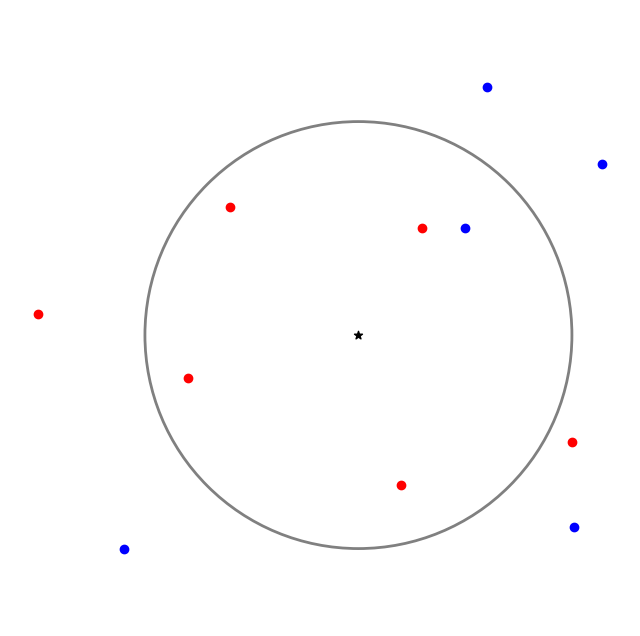

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))   # nuova figura di dimensione 8x8

ax.scatter(center[0], center[1], color='black', marker='*')   # disegno del punto al centro come una stella
circle = patches.Circle(center, 1, edgecolor='gray', facecolor= None, alpha=1, linewidth=2, fill=False)   # definisce cerchio centrato in center

# disegna i punti con etichetta 1 definendo la lista delle coordinate x e y usando
# list comprehension (vedere)
ax.scatter([x for x,y,t in points if t == 1], [y for x,y,t in points if t == 1], color = 'blue', marker='o')
# stessa cosa con etichetta 0
ax.scatter([x for x,y,t in points if t == 0], [y for x,y,t in points if t == 0], color = 'red', marker='o')

# aggiunge cenchio al disegno
ax.add_patch(circle)
ax.axis('equal')
ax.axis('off')

# salve disegno
plt.savefig('01-28-knn.png', dpi=120, bbox_inches='tight')

plt.show()


In [26]:
def euclidean_dist(a0,a1):
    return np.linalg.norm(a0-a1)

def selection_sort(a, x, k=None, key=None):
    # x: oggetto da classificare
    # k: numero di indici da ritornare
    # key: funzione di distanza tra due oggetti x e y

    if k == None or k > len(a) or k < 0:
        k=len(a)
    if key == None:
        key = lambda y, _: y

    idxs = [] # idxs[:i] le posizioni dei primi elementi di a in ordine di grandezza
    for i in range(k):
        # il migliore indice trovato
        m = None
        for j,v in enumerate(a):
            if m == None or key(v,x) < key(a[m],x):
                if j not in idxs: 
                    m=j
        idxs.append(m)
    return idxs

# mode = moda, ossia l'elemento piu' frequente
def mode(a):
    # ritorna a senza ripetizioni (elementi unici) + una lista dei conteggi per ogni elemento
    itms, cnts = np.unique(np.array(a), return_counts=True)
    # argmax: trova l'indice che massimizza il valore in cnts
    # max: trova il valore massimo
    return itms[np.argmax(cnts)], max(cnts)

class KNN(object):
    def __init__(self, k = 5, distance = None):
        self.k = k
        if distance == None:
            self._dist = euclidean_dist
        else:
            self._dist = distance
    
    def fit(self, X, y):
        self.X = X  # X è una matrice n x d (n campioni, d features)
        self.y = y  # y è un array di dimensione n
        
    def predict(self, x):        
        # Ottiene gli indici dei k punti più vicini
        k_indices = selection_sort(self.X, x, k=5, key = self._dist)
        
        # Prende le etichette corrispondenti
        return mode(self.y[k_indices])


# complessita
**efficiente**: se $k$ piccolo allora richiede $\Theta(k n)$ operazioni

**kd tree**: permette di scendere a $\Theta(k log n)$

**costruzione kd tree**: $\Theta(k nlogn)$ per ogni dimension

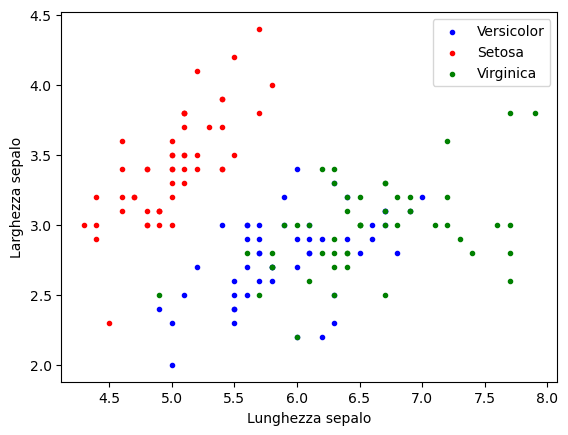

In [27]:
import os
import pandas as pd
s = os.path.join('dataset', '01-02-iris.csv')
df = pd.read_csv(s, header=None, encoding='utf-8')

# iloc: e' il dataframe indicizzabile usando gli interi
# X valori del dataset
X = df.iloc[:, [0,1]].values
# etichette
y = df.iloc[:,4].values

versicolor = X[np.where(y == 'Iris-versicolor')]
setosa = X[np.where(y == 'Iris-setosa')]
virginica = X[np.where(y == 'Iris-virginica')]

# ATTENZIONE: devo scegliere un sott'insieme di features ottimale
# da usare come training set per la classificazione.
X = df.iloc[:, [0,1]].values
y = df.iloc[:, 4].values

plt.scatter(versicolor[:,0], versicolor[:,1], color='blue', marker='.', label='Versicolor')
plt.scatter(setosa[:,0], setosa[:,1], color='red', marker='.', label='Setosa')
plt.scatter(virginica[:,0], virginica[:,1], color='green', marker='.', label='Virginica')
plt.xlabel('Lunghezza sepalo')
plt.ylabel('Larghezza sepalo')
plt.legend()

plt.savefig('01-24-iris_01.png', dpi=120, bbox_inches='tight')


# classificazione e testing
**scegliere le features**: nel codice sopra visualizziamo i punti nel grafo e gli diamo un'etichetta.

**punti**: hanno due cordinate, e possiamo scegliere un sottoinsieme a nostro piacimento rispetto alle features di ogni iris per posizionare i punti nel grafo.

**obiettivo**: identificare la combinazione di features che divide meglio le etichette.

**training set**: addestrare il classificatore, in kNN il training set non serve ad addestrare, dato che non devo addestrare un cazzo di nulla

**test set**: viene usato per testare il classificatore, confrontando i risultati del classificatore con i dati reali.

**train_test_split**: dato un dataset in input voglio dividerlo in train e test.


## esercizio svolto
si vuole mantenere la distribuzione delle etichette in train set e test set, creare una procedura `train_test_split` che lo fa!

In [30]:
def train_test_split(X, y, train_size = 0.7):
    etichette = np.unique(y)
    n = X.shape[0]

    train_idxs = []
    for lab in etichette:
        print(np.where(y==lab))
        # a = np.where(y==lab)[0]
        a, = np.where(y==lab)
        n0 = a.shape[0]
        train_idxs.append( np.random.choice(a, size=int(n0*train_size), replace=False))
    train_idxs = np.concatenate(train_idxs)
    test_idxs = np.setdiff1d(np.arange(n), train_idxs)
    
    return X[train_idxs], y[train_idxs], X[test_idxs], y[test_idxs]


X = df.iloc[:, :-1].values  # i valori in tutte le righe e tutte le colonne tranne l'ultima
y = df.iloc[:, 4].values # i valori nell'ultima colonna
#y = df.iloc[:, -1].values # alteternativa alla precedente

X_train, y_train, X_test, y_test = train_test_split(X, y)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),)
(array([50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
       67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
       84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),)
(array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149]),)


* `y == lab`: ritorna un array di bool $b$, dove per ogni $y_i \in y$ allora $b_i \in b$ e' true se $y_i = lab$, altrimenti e' false.
* `np.where(y == lab)`: ritorna gli indici in cui `y==lab` e' true
* `train_idxs.append(...)`: scegli a random gli indici da mettere nel train set.
* `np.concatenate(train_idxs)`: concatena gli array!
* `np.setdiff1d`:  fai la differenza degli indici per ottenere il test set

In [31]:
knn = KNN()
# memorizza il dataset per addestrare 
knn.fit(X_train, y_train)
for x, t in zip(X_test[:10], y_test[:10]):
    print(x,t, knn.predict(x))

[5.1 3.5 1.4 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[4.9 3.  1.4 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.  3.4 1.5 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[4.4 2.9 1.4 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.4 3.9 1.3 0.4] Iris-setosa ('Iris-setosa', np.int64(5))
[4.6 3.6 1.  0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.  3.  1.6 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.2 3.4 1.4 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.5 4.2 1.4 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.1 3.4 1.5 0.2] Iris-setosa ('Iris-setosa', np.int64(5))


## esercizio
studiare l'importanza delle quattro feature individuando la piu inutile

In [ ]:
X = df.iloc[:, :4].values
y = df.iloc[:, 4].values

X_train, y_train, X_test, y_test =train_test_split(X, y)
knn = KNN()
knn.fit(X_train, y_train)

d = X.shape[1]

preds = np.array([knn.predict(x)[0] for x in X_test]) == y_test
print('Accuratezza ', preds.sum()/preds.shape[0])

# f itera in [0,1,2,3] avendo 4 features
for f in range(X_train.shape[1]):
    # togli f da [0,1,2,...,d-1]
    features = np.setdiff1d(np.arange(d), np.array([f]))
    print(features)

    # allena in base alle features selezionate per questa iterazione
    knn = KNN()
    knn.fit(X_train[:,features], y_train)
    
    # crea il vettore dove indico le predizioni azzeccate.
    preds = np.array([knn.predict(X[features])[0] for x in X_test] == y_test)
    print('Acc: ', preds.sum()/preds.shape[0])


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),)
(array([50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
       67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
       84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),)
(array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149]),)
Accuratezza  0.9777777777777777
[1 2 3]
Acc:  0.9555555555555556
[0 2 3]
Acc:  0.9555555555555556
[0 1 3]
Acc:  0.8888888888888888
[0 1 2]
Acc:  0.9555555555555556


* `np.arra`